<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/cluster_de_estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install scikit-learn-extra

NameError: name 'scikit' is not defined

In [10]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
#from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Cargar los datos
df = pd.read_csv('Ejemplo Estudiantes.csv')
print("Primeras filas del dataset:")
print(df.head())
print("\
Información del dataset:")
print(df.info())

Primeras filas del dataset:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes
0      Lucia          7.0       6.5      9.2       8.6       8.0
1      Pedro          7.5       9.4      7.3       7.0       7.0
2       Ines          7.6       9.2      8.0       8.0       7.5
3       Luis          5.0       6.5      6.5       7.0       9.0
4     Andres          6.0       6.0      7.8       8.9       7.3
Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Estudiante   10 non-null     object 
 1   Matematicas  10 non-null     float64
 2   Ciencias     10 non-null     float64
 3   Espanol      10 non-null     float64
 4   Historia     10 non-null     float64
 5   Deportes     10 non-null     float64
dtypes: float64(5), object(1)
memory usage: 612.0+ bytes
None


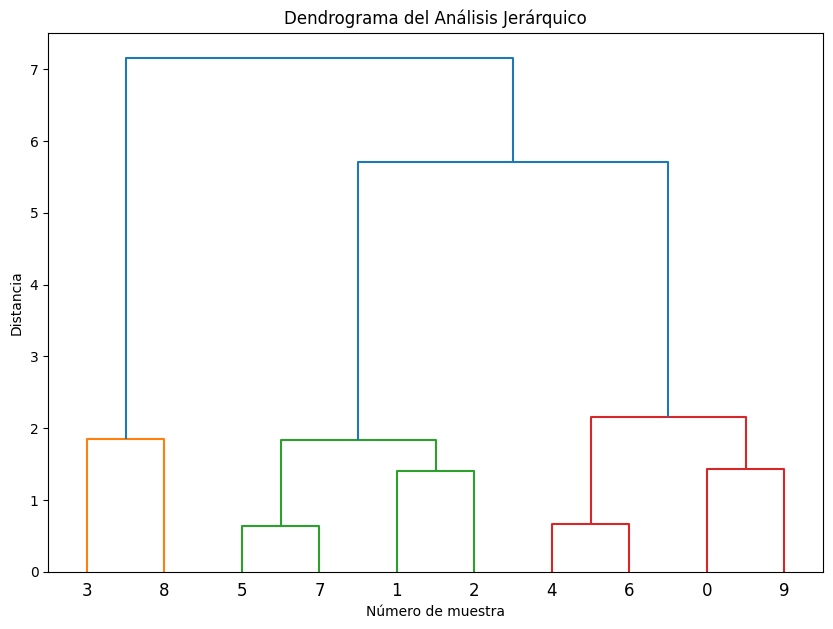

Resultados del Clustering Jerárquico:
Cluster 0:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
0      Lucia          7.0       6.5      9.2       8.6       8.0   
4     Andres          6.0       6.0      7.8       8.9       7.3   
6     Carlos          6.3       6.4      8.2       9.0       7.2   
9      Maria          6.8       7.2      8.7       9.0       7.0   

   Cluster_Jerarquico  
0                   0  
4                   0  
6                   0  
9                   0  
Cluster 1:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
3       Luis          5.0       6.5      6.5       7.0       9.0   
8      Sonia          6.0       6.0      6.5       5.5       8.7   

   Cluster_Jerarquico  
3                   1  
8                   1  
Cluster 2:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
1      Pedro          7.5       9.4      7.3       7.0       7.0   
2       Ines          7.6       9.2      8.0       8.0 

In [11]:
# Preparar los datos para clustering
# Seleccionar solo las columnas numéricas
X = df.select_dtypes(include=['float64', 'int64'])

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear el linkage para el clustering jerárquico
linkage_matrix = linkage(X_scaled, method='ward')

# Crear el dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Dendrograma del Análisis Jerárquico')
plt.xlabel('Número de muestra')
plt.ylabel('Distancia')
plt.show()

# Realizar clustering jerárquico con 3 clusters
n_clusters = 3
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Añadir las etiquetas al dataframe original
df['Cluster_Jerarquico'] = hierarchical_labels

# Mostrar los resultados por cluster
print("\
Resultados del Clustering Jerárquico:")
for i in range(n_clusters):
    print(f"\
Cluster {i}:")
    print(df[df['Cluster_Jerarquico'] == i])

Métricas de evaluación:
Clustering Jerárquico:
Silhouette Score: 0.547
Calinski-Harabasz Score: 17.947
Davies-Bouldin Score: 0.551
K-means:
Silhouette Score: 0.547
Calinski-Harabasz Score: 17.947
Davies-Bouldin Score: 0.551


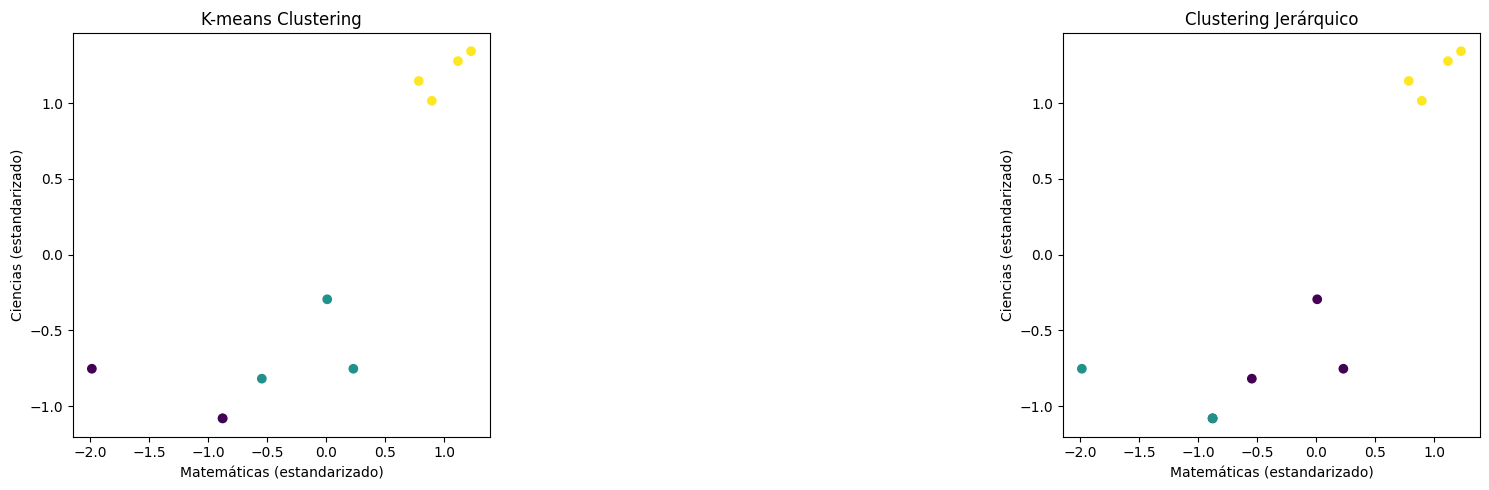

Clasificación final de estudiantes:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
0      Lucia          7.0       6.5      9.2       8.6       8.0   
1      Pedro          7.5       9.4      7.3       7.0       7.0   
2       Ines          7.6       9.2      8.0       8.0       7.5   
3       Luis          5.0       6.5      6.5       7.0       9.0   
4     Andres          6.0       6.0      7.8       8.9       7.3   
5        Ana          7.8       9.6      7.7       8.0       6.5   
6     Carlos          6.3       6.4      8.2       9.0       7.2   
7       Jose          7.9       9.7      7.5       8.0       6.0   
8      Sonia          6.0       6.0      6.5       5.5       8.7   
9      Maria          6.8       7.2      8.7       9.0       7.0   

   Cluster_Jerarquico  Cluster_Kmeans  
0                   0               1  
1                   2               2  
2                   2               2  
3                   1               0  
4              

In [14]:
# Realizar K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Realizar K-medoids clustering
#kmedoids = KMedoids(n_clusters=3, random_state=42)
#kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Calcular métricas para cada método
def calculate_metrics(X, labels):
    silhouette = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    return silhouette, calinski, davies

# Calcular métricas para cada método
metrics_hierarchical = calculate_metrics(X_scaled, hierarchical_labels)
metrics_kmeans = calculate_metrics(X_scaled, kmeans_labels)
#metrics_kmedoids = calculate_metrics(X_scaled, kmedoids_labels)

# Mostrar las métricas
print("Métricas de evaluación:")
print("\
Clustering Jerárquico:")
print(f"Silhouette Score: {metrics_hierarchical[0]:.3f}")
print(f"Calinski-Harabasz Score: {metrics_hierarchical[1]:.3f}")
print(f"Davies-Bouldin Score: {metrics_hierarchical[2]:.3f}")

print("\
K-means:")
print(f"Silhouette Score: {metrics_kmeans[0]:.3f}")
print(f"Calinski-Harabasz Score: {metrics_kmeans[1]:.3f}")
print(f"Davies-Bouldin Score: {metrics_kmeans[2]:.3f}")

#print("\
#K-medoids:")
#print(f"Silhouette Score: {metrics_kmedoids[0]:.3f}")
#print(f"Calinski-Harabasz Score: {metrics_kmedoids[1]:.3f}")
#print(f"Davies-Bouldin Score: {metrics_kmedoids[2]:.3f}")

# Visualización de los clusters (usando las dos primeras características)
plt.figure(figsize=(15, 5))

# Plot para K-means
plt.subplot(131)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('K-means Clustering')
plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')

# Plot para K-medoids
#plt.subplot(132)
#plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmedoids_labels, cmap='viridis')
#plt.title('K-medoids Clustering')
#plt.xlabel('Matemáticas (estandarizado)')
#plt.ylabel('Ciencias (estandarizado)')

# Plot para Clustering Jerárquico
plt.subplot(133)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels, cmap='viridis')
plt.title('Clustering Jerárquico')
plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')

plt.tight_layout()
plt.show()

# Añadir las etiquetas de todos los métodos al dataframe
df['Cluster_Kmeans'] = kmeans_labels
#df['Cluster_Kmedoids'] = kmedoids_labels

# Mostrar el dataframe final con todas las clasificaciones
print("\
Clasificación final de estudiantes:")
print(df)

Clasificación de nuevos individuos:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
0     Nuevo1          7.0       7.0      9.0       8.0       7.0   
1     Nuevo2          6.0       6.0      7.0       8.0       7.0   
2     Nuevo3          8.0       9.0      8.0       8.5       7.5   

   Cluster_Kmeans  
0               1  
1               1  
2               2  
Conteo de nuevos individuos por cluster:
Cluster_Kmeans
1    2
2    1
Name: count, dtype: int64
Centroides en la escala original:
   Matematicas  Ciencias  Espanol  Historia  Deportes  Cluster
0        5.500     6.250    6.500     6.250     8.850        0
1        6.525     6.525    8.475     8.875     7.375        1
2        7.700     9.475    7.625     7.750     6.750        2


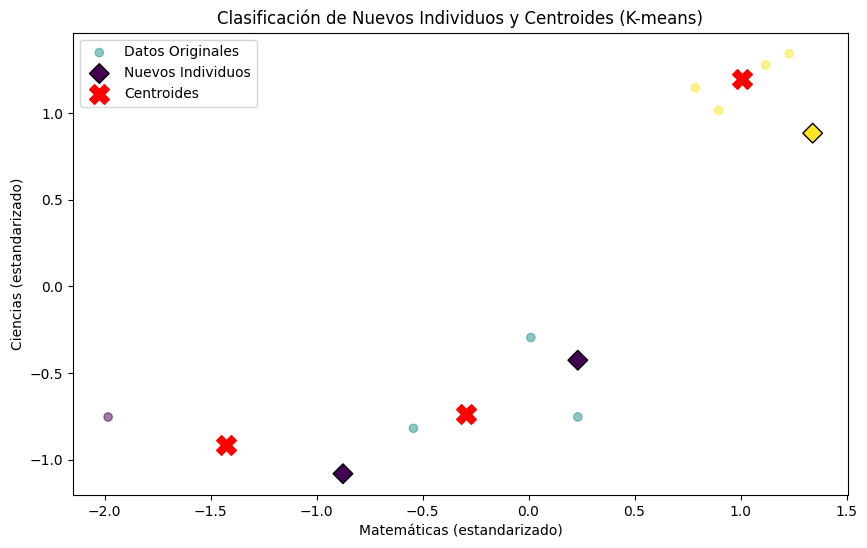

Conteo de individuos en cada cluster (Datos originales - K-means):
Cluster_Kmeans
0    2
1    4
2    4
Name: count, dtype: int64
Tabla de centroides:
   Matematicas  Ciencias  Espanol  Historia  Deportes  Cluster
0        5.500     6.250    6.500     6.250     8.850        0
1        6.525     6.525    8.475     8.875     7.375        1
2        7.700     9.475    7.625     7.750     6.750        2
Proceso de clasificación de nuevos individuos completado.


In [15]:
# Clasificar nuevos individuos utilizando el modelo de K-means

# Crear un DataFrame con nuevos individuos
nuevos_datos = pd.DataFrame({
    'Estudiante': ['Nuevo1', 'Nuevo2', 'Nuevo3'],
    'Matematicas': [7.0, 6.0, 8.0],
    'Ciencias': [7.0, 6.0, 9.0],
    'Espanol': [9.0, 7.0, 8.0],
    'Historia': [8.0, 8.0, 8.5],
    'Deportes': [7.0, 7.0, 7.5]
})

# Estandarizar usando el mismo scaler
X_nuevos = nuevos_datos[['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']]
X_nuevos_scaled = scaler.transform(X_nuevos)

# Predecir los clusters para los nuevos individuos usando K-means
nuevos_clusters = kmeans.predict(X_nuevos_scaled)

# Añadir la asignación de cluster al DataFrame
nuevos_datos['Cluster_Kmeans'] = nuevos_clusters
print("Clasificación de nuevos individuos:")
print(nuevos_datos)

# Contar el número de nuevos individuos por cluster
conteo_nuevos = nuevos_datos['Cluster_Kmeans'].value_counts().sort_index()
print("\
Conteo de nuevos individuos por cluster:")
print(conteo_nuevos)

# Obtener los centroides del K-means (en el espacio estandarizado) y transformarlos de vuelta a la escala original
centroides_scaled = kmeans.cluster_centers_
centroides = scaler.inverse_transform(centroides_scaled)
centroides_df = pd.DataFrame(centroides, columns=['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes'])
centroides_df['Cluster'] = centroides_df.index

print("\
Centroides en la escala original:")
print(centroides_df)

# Visualizar los nuevos individuos y los centroides en un gráfico
plt.figure(figsize=(10, 6))

# Usaremos las dos primeras dimensiones (Matemáticas y Ciencias) para la visualización
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, label='Datos Originales')

# Graficar nuevos individuos
plt.scatter(X_nuevos_scaled[:, 0], X_nuevos_scaled[:, 1], c=nuevos_clusters, cmap='viridis', marker='D', s=100, edgecolor='black', label='Nuevos Individuos')

# Graficar centroides en el espacio estandarizado (usamos los mismos índices: las dos primeras dimensiones)
plt.scatter(centroides_scaled[:, 0], centroides_scaled[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')
plt.title('Clasificación de Nuevos Individuos y Centroides (K-means)')
plt.legend()
plt.show()

# Mostramos una tabla resumen de la cantidad de individuos en cada cluster (incluyendo los nuevos)
# Primero para el dataset original, luego para los nuevos
conteo_original = df['Cluster_Kmeans'].value_counts().sort_index()
print("\
Conteo de individuos en cada cluster (Datos originales - K-means):")
print(conteo_original)

print("\
Tabla de centroides:")
print(centroides_df)

print("\
Proceso de clasificación de nuevos individuos completado.")